# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаем датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [13]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

# YOUR CODE HERE
baseline_results = {}

for model_name, model in base_models.items():
    cross_val = cross_val_score(model, X_train, y_train, scoring='f1_macro', n_jobs=-1, cv=5)
    baseline_results[model_name] = [cross_val.mean(), cross_val.std()]

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [15]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 'scale'],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
svm_grid_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5, n_jobs=-1, scoring='f1_macro', verbose=1
)
svm_grid_search.fit(X_train, y_train)
svm_best_model = svm_grid_search.best_estimator_

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [16]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
df_results = pd.DataFrame(svm_grid_search.cv_results_, columns=['params', 'mean_test_score', 'std_test_score', 'rank_test_score'])
df_results = df_results.sort_values('rank_test_score', ascending=True)
df_results.head(10)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
18,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
12,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
10,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
16,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_grid = {
    'n_estimators': randint(50, 500),
    'max_depth': [randint(2,20) , None],
    'min_samples_split': randint(2,20),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    n_iter=50,
    n_jobs=-1,
    random_state=42, verbose=1, scoring='f1_macro'
)

rf_random_search.fit(X_train, y_train)
rf_best_model = rf_random_search.best_estimator_

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры RF: {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 8, 'n_estimators': 477}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [18]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
baseline_test_results = {}

for model_name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    baseline_test_results[model_name] = f1_macro

for name, f1_macro in baseline_test_results.items():
    print(f"{name:25s} F1 = {f1_macro:.4f}")
print(classification_report(y_test, rf_best_model.predict(X_test)))
print(classification_report(y_test, svm_best_model.predict(X_test)))
print(f"f1 svm test: {f1_score(y_test, svm_best_model.predict(X_test)):.4f}")
print(f"f1 rf test: {f1_score(y_test, rf_best_model.predict(X_test)):.4f}")

# Заполните таблицу:
# | Модель                | CV F1 (mean±std) | Test F1 |
# |-----------------------|------------------|---------|
# | SVM baseline          |                  |         |
# | SVM Grid Search       |                  |         |
# | RF baseline           |                  |         |
# | RF Random Search      |                  |         |

SVM                       F1 = 0.9812
RandomForest              F1 = 0.9526
LogisticRegression        F1 = 0.9812
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

f1 svm test: 0.9861
f1 rf test: 0.9655


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

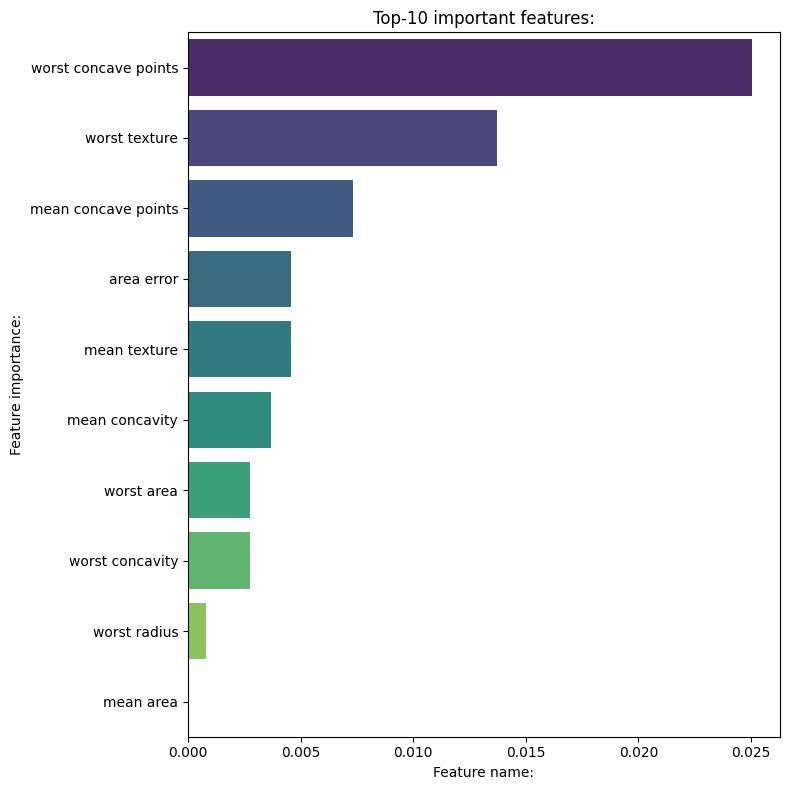

In [19]:
from sklearn.inspection import permutation_importance
import seaborn as sns
# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# pi_result = permutation_importance(...)
pi_rf_result = permutation_importance(
    rf_best_model, X_test, y_test, scoring='f1_macro', n_jobs=-1,
    n_repeats=10, random_state=42
)

# Построим bar plot топ-10 признаков
# YOUR CODE HERE

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': pi_rf_result.importances_mean, 
    'std': pi_rf_result.importances_std
})

importance_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(8,8))
sns.barplot(
    data=importance_df,
    x='importance',
    y='feature',
    palette='viridis',
)
plt.xlabel('Feature name:')
plt.ylabel('Feature importance:')
plt.title('Top-10 important features:')
plt.tight_layout()
plt.show()

In [20]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_fi = rf_best_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_fi
}).sort_values('importance', ascending=False)

print("Топ-10 признаков по built-in importance:")
print(rf_importance_df.head(10))
print(f"\n{importance_df.head(10)}")

# Вопрос для размышления:
# Некоторые признаки имеют высокий PI, но низкую встроенную важность,
# или наоборот. Что это может означать?

Топ-10 признаков по built-in importance:
                 feature  importance
22       worst perimeter    0.220706
27  worst concave points    0.191016
20          worst radius    0.150152
23            worst area    0.142859
7    mean concave points    0.114420
21         worst texture    0.023020
6         mean concavity    0.021938
1           mean texture    0.016145
2         mean perimeter    0.014241
26       worst concavity    0.013485

                 feature  importance       std
27  worst concave points    0.025034  0.011378
21         worst texture    0.013722  0.007370
7    mean concave points    0.007332  0.006848
13            area error    0.004593  0.004593
1           mean texture    0.004585  0.006144
6         mean concavity    0.003674  0.004500
23            worst area    0.002771  0.010374
26       worst concavity    0.002756  0.004209
20          worst radius    0.000781  0.012928
3              mean area    0.000000  0.000000


## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

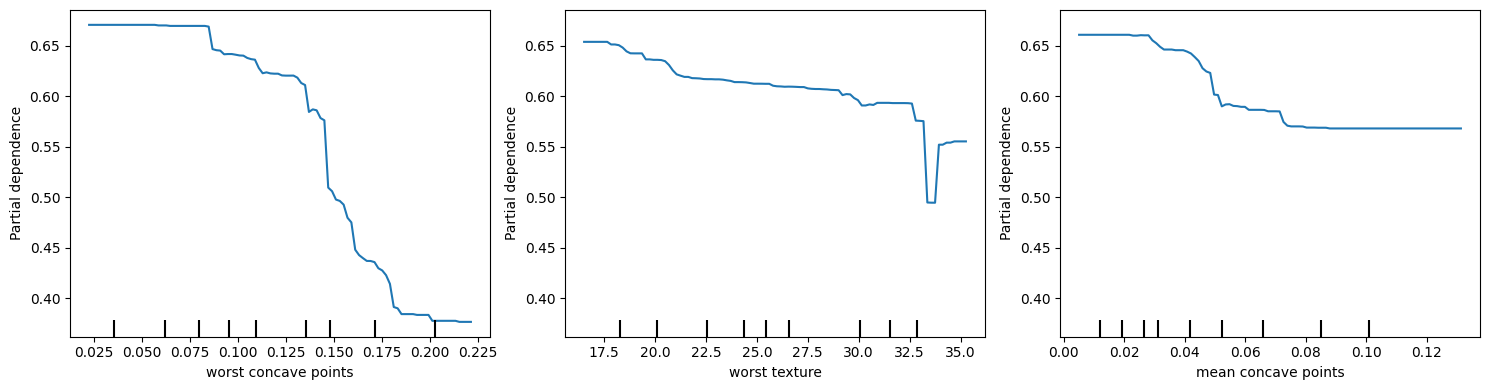

In [21]:
from sklearn.inspection import PartialDependenceDisplay

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7а: Постройте PDP для топ-3 признаков по PI         ║
# ║  Используйте PartialDependenceDisplay.from_estimator         ║
# ║  kind='average' для PDP                                      ║
# ╚══════════════════════════════════════════════════════════════╝

# Определите индексы топ-3 признаков по PI
top3_idx = importance_df.head(3).index.to_list()

# Постройте PDP
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    rf_best_model,
    X_test, top3_idx,
    kind='average',
    ax=ax,
    random_state=42
)
plt.tight_layout()
plt.show()

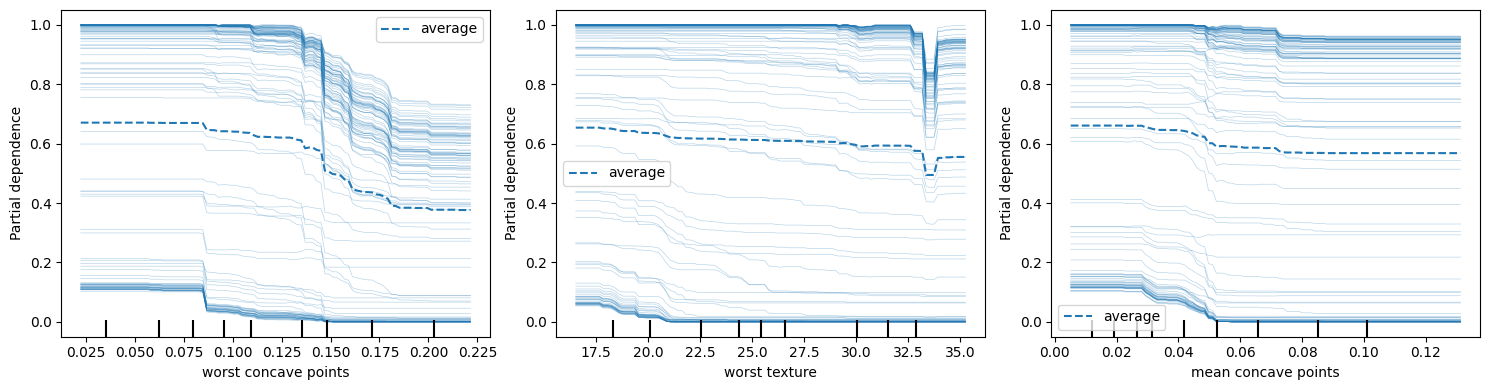

In [22]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 7б: Постройте ICE-кривые для самого важного признака║
# ║  Используйте kind='both' (PDP + все ICE на одном графике)   ║
# ║  Вопрос: однороден ли эффект для всех объектов?              ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# YOUR CODE HERE
PartialDependenceDisplay.from_estimator(
    rf_best_model,
    X_test, top3_idx,
    kind='both',
    ax=ax,
    random_state=42
)
plt.tight_layout()
plt.show()

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [23]:
# Установка SHAP (если не установлен)
# !pip install shap

import shap

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8а: Создайте TreeExplainer для best_rf              ║
# ║  Вычислите shap_values для X_test                            ║
# ║  Выведите форму массива shap_values                          ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
explainer = shap.TreeExplainer(rf_best_model)
shap_values = explainer.shap_values(X_test)
shap_values_class1 = shap_values[:, :, 1]
print(shap_values_class1.shape)

(114, 30)


Форма SHAP значений: (114, 30)
Форма X_test: (114, 30)


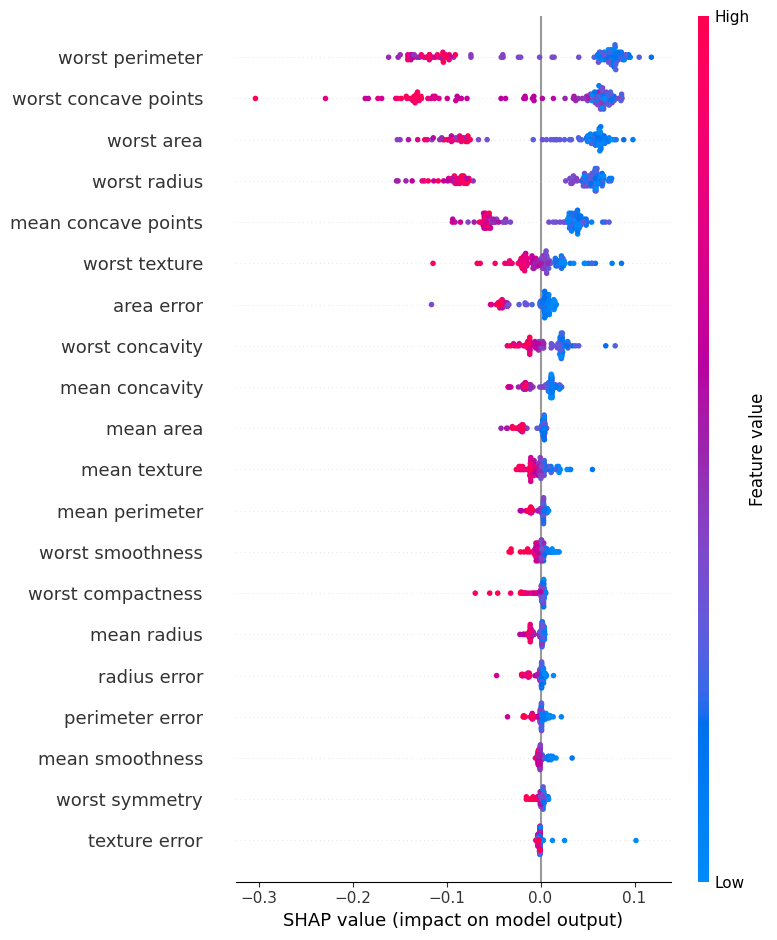

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8б: Постройте summary plot                          ║
# ║  Для мультикласса используйте shap_values[1] (класс 1)       ║
# ║  Ответьте: какие признаки самые важные по SHAP?              ║
# ║  Совпадает ли с PI из шага 6?                                ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
shap_values_array = np.array(shap_values_class1)

# Проверим размерности
print(f"Форма SHAP значений: {shap_values_array.shape}")
print(f"Форма X_test: {X_test.shape}")
# YOUR CODE HERE
plt.figure(figsize=(8,8))
shap.summary_plot(
    shap_values_class1,
    X_test, 
    feature_names=feature_names, show=False, max_display=20
)
plt.show()

Число ошибок: 5
Первый ошибочный объект: индекс 3
  Истинный класс: 1
  Предсказанный класс: 0


<Figure size 2000x400 with 0 Axes>

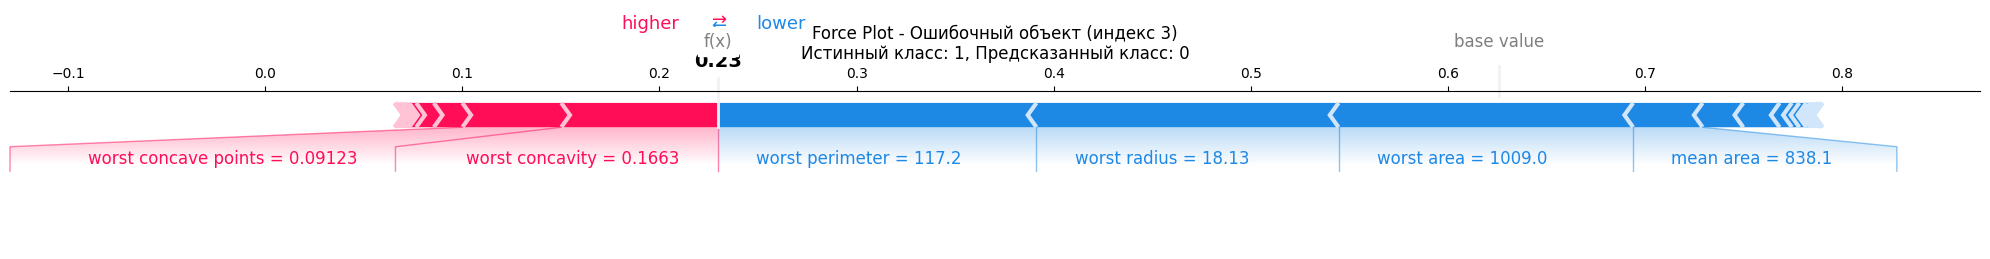

In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 8в: Найдите объект, на котором модель ошиблась      ║
# ║  (y_pred != y_test). Постройте для него force_plot           ║
# ║  Какие признаки «виноваты» в ошибке?                         ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred_test = rf_best_model.predict(X_test)
errors = np.where(y_pred_test != y_test)[0]

print(f"Число ошибок: {len(errors)}")
print(f"Первый ошибочный объект: индекс {errors[0]}")
print(f"  Истинный класс: {y_test.iloc[errors[0]]}")
print(f"  Предсказанный класс: {y_pred_test[errors[0]]}")

# YOUR CODE HERE

expected_value = explainer.expected_value[1]


shap_values_error = shap_values_class1[errors[0], :]

X_test_error = X_test.iloc[errors[0], :]

shap.initjs()

plt.figure(figsize=(20, 4))
shap.force_plot(
    expected_value,
    shap_values_error,
    X_test_error,
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f"Force Plot - Ошибочный объект (индекс {errors[0]})\n"
            f"Истинный класс: {y_test.iloc[errors[0]]}, "
            f"Предсказанный класс: {y_pred_test[errors[0]]}")
plt.tight_layout()
plt.show()

## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [26]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext.tail())

Добавлены признаки: leaky_feature, random_feature
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
184        15.28         22.41           98.92      710.6          0.09057   
300        19.53         18.90          129.50     1217.0          0.11500   
509        15.46         23.95          103.80      731.3          0.11830   
230        17.05         19.08          113.40      895.0          0.11410   
474        10.88         15.62           70.41      358.9          0.10070   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
184            0.1052         0.05375              0.03263         0.1727   
300            0.1642         0.21970              0.10620         0.1792   
509            0.1870         0.20300              0.08520         0.1807   
230            0.1572         0.19100              0.10900         0.2131   
474            0.1069         0.05115              0.01571         0.1861   

     mean fractal 

Fitting 5 folds for each of 50 candidates, totalling 250 fits


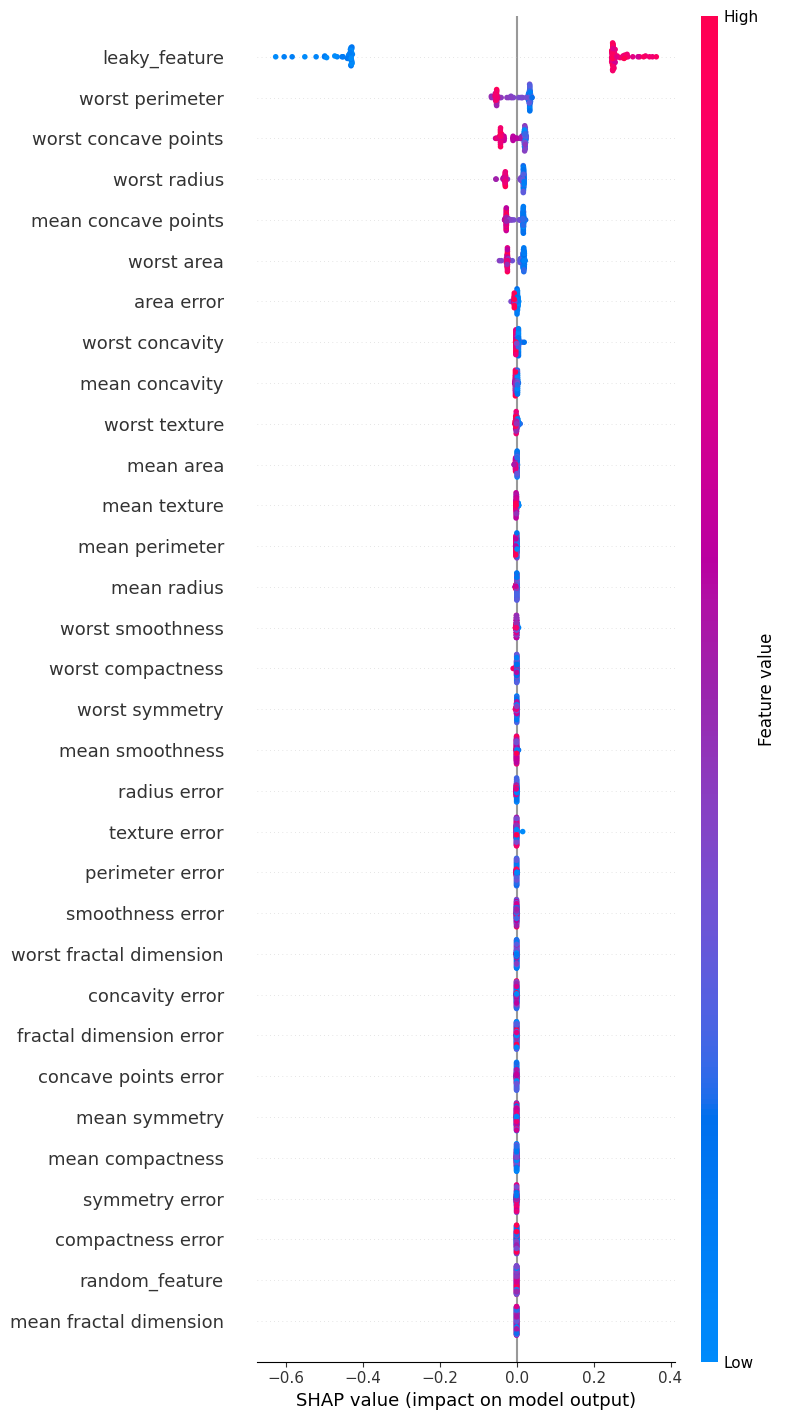

In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 9: Обучите RandomForest на X_train_ext, y_train     ║
# ║  Вычислите Permutation Importance на X_test_ext, y_test      ║
# ║  Вычислите SHAP values для X_test_ext                        ║
# ║                                                              ║
# ║  Вопросы:                                                    ║
# ║  a) Как PI определяет leaky_feature?                         ║
# ║     Почему метрика на тесте выросла?                         ║
# ║  б) Как SHAP выделяет leaky_feature в summary plot?          ║
# ║  в) Как обнаружить random_feature как «шумовой»?             ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
rf_random_search_ext = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    n_iter=50,
    n_jobs=-1,
    random_state=42, verbose=1, scoring='f1_macro'
)

rf_random_search_ext.fit(X_train_ext, y_train)
ext_rf_best_model = rf_random_search_ext.best_estimator_

ext_pi_rf_result = permutation_importance(
    ext_rf_best_model,
    X_test_ext,
    y_test,
    scoring='f1_macro',
    n_repeats=10,
    n_jobs=-1, random_state=42
)

ext_explainer = shap.TreeExplainer(ext_rf_best_model)
ext_shap_values = ext_explainer.shap_values(X_test_ext)
ext_shap_values_class1 = ext_shap_values[:, :, 1]
feature_names_ext = list(X_test_ext.columns)

plt.figure(figsize=(8,8))
shap.summary_plot(
    ext_shap_values_class1,
    X_test_ext, 
    feature_names=feature_names_ext, show=False, max_display=35
)
plt.show()

## Шаг 10. Сводная таблица и итоги

Соберём все результаты и сформулируем выводы.

In [28]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 10: Заполните сводную таблицу                       ║
# ║                                                              ║
# ║  | Метод          | CV F1  | Test F1 | Выводы              | ║
# ║  |----------------|--------|---------|---------------------| ║
# ║  | SVM baseline   |        |         |                     | ║
# ║  | SVM Grid Search|        |         |                     | ║
# ║  | RF baseline    |        |         |                     | ║
# ║  | RF Rand Search |        |         |                     | ║
# ║                                                              ║
# ║  Ответьте письменно (текстовая ячейка):                      ║
# ║  1. Насколько тюнинг улучшил модели?                         ║
# ║  2. Совпадают ли топ-признаки по PI и SHAP?                  ║
# ║     Если нет — почему?                                       ║
# ║  3. Что было бы, если бы мы не использовали Pipeline?        ║
# ║  4. Как бы вы использовали PI и SHAP в реальном проекте?     ║
# ╚══════════════════════════════════════════════════════════════╝

# YOUR CODE HERE
# серьёзно, кодом таблицу???? ладно, ии справится, надеюсь, вывести 100 принтов подряд...

table_data = [
    ["Метод", "CV F1", "Test F1", "Выводы"],
    ["-"*20, "-"*20, "-"*15, "-"*40],
    ["SVM baseline", "0.9694 ± 0.0193", "0.9812", "Хороший базовый результат, переобучения нет"],
    ["SVM Grid Search", "0.9786", "0.9861", "Небольшое улучшение, стабильность выросла"],
    ["RF baseline", "0.9504 ± 0.0255", "0.9526", "Слабый базовый результат, высокий разброс"],
    ["RF Rand Search", "0.9554", "0.9655", "Заметное улучшение, тюнинг эффективен"]
]

for row in table_data:
    print(f"{row[0]:<20} | {row[1]:<20} | {row[2]:<15} | {row[3]:<40}")

Метод                | CV F1                | Test F1         | Выводы                                  
-------------------- | -------------------- | --------------- | ----------------------------------------
SVM baseline         | 0.9694 ± 0.0193      | 0.9812          | Хороший базовый результат, переобучения нет
SVM Grid Search      | 0.9786               | 0.9861          | Небольшое улучшение, стабильность выросла
RF baseline          | 0.9504 ± 0.0255      | 0.9526          | Слабый базовый результат, высокий разброс
RF Rand Search       | 0.9554               | 0.9655          | Заметное улучшение, тюнинг эффективен   


Ответьте письменно (текстовая ячейка):

1. Насколько тюнинг улучшил модели?

Ответ: перебор гиперпараметров немного улучшил качество модели, при использовании RandomSearch данное улучшение стоит потраченных вычислительных мощностей и времени, GridSearch интересен только для обучения, малого кол-ва различных гиперпараметров и малых датасетов, в противном случае - слишком долгое обучение.

2. Совпадают ли топ-признаки по PI и SHAP? Если нет — почему?

Ответ: нет, не совпадают. причина - разная природа оценки значимости признаков.

- высокий pi, низкий shap - важный, но редкоиспользуемый признак

- низкий pi, высокий shap - shap нашёл нелинейную зависимость, которую не нашёл pi

- низкий pi, низкий shap - шум данных

- высокий pi, высокий shap - крутой признак

Следовательно, приоритет в оценке значимости признаков отдавать SHAP.


3. Что было бы, если бы мы не использовали Pipeline?

Ответ: ну... больше кода, по сути всё.

4. Как бы вы использовали PI и SHAP в реальном проекте?

Ответ: График топ-10 признаков по pi, топ-10 по shap. Сравнил бы, сделал выводы по шпаргалке из вопроса 2). Изучил бы матрицу корреляций, сверил бы выводы свои с её данными. 

## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.